## Dimensionality Reduction

### Load relevant libraries

In [2]:
import os
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import umap

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind

### Read in the Data

In [3]:
# Set working directory (necessary until 2019 data comes out)
path = 'C:/Users/caanm/OneDrive/Documents/Project Portfolio/OSMH/Data'
os.chdir(path)

In [4]:
df = pd.read_csv('cleaned_data.csv')

### PCA

In [5]:
### Identify feature columns

df_full = df.copy()

# Encoded numerical columns
pca_features = [col for col in df_full.columns
                if col.endswith('_enc') and col not in ['comments_enc', 'treatment_enc']]

# Add support score
pca_features.append('support_score')

pca_features

['self_employed_enc',
 'tech_company_enc',
 'obs_consequence_enc',
 'family_history_enc',
 'work_interfere_enc',
 'benefits_enc',
 'care_options_enc',
 'wellness_program_enc',
 'seek_help_enc',
 'anonymity_enc',
 'leave_enc',
 'mental_vs_physical_enc',
 'support_score']

In [6]:
### Impute median for missing values
imputer = SimpleImputer(strategy='median')
X_pca_ready = imputer.fit_transform(df[pca_features])

In [7]:
### Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca_ready)

In [8]:
### Fit PCA
pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X_scaled)

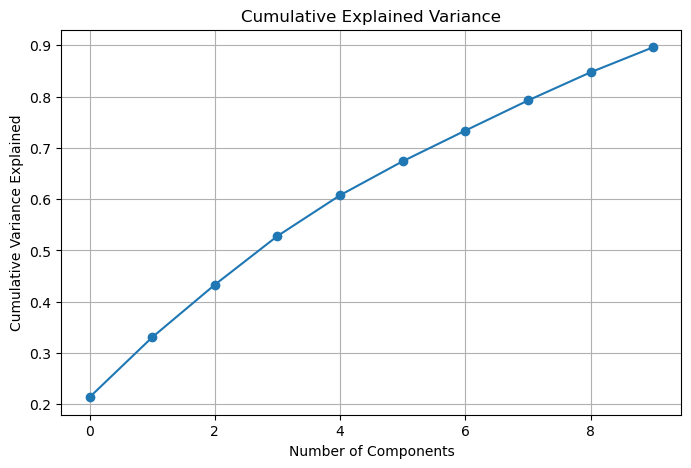

In [9]:
### Examine Explained Variance
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance Explained')
plt.grid(True)
plt.show()

##### When including all 14 variables, we see diminishing returns in explained variance after 10 PCs
> ##### 10 PCs already gives us 90% of explained variance
##### Will use this as the default set and check model performance against different options to validate

### PC1

In [10]:
### Extract PC1 Loadings
feature_names = list(pca_features)
pc1_loadings = pd.Series(pca.components_[0], index=feature_names, name='PC1_Loading')

# Sort by abs value
pc1_sorted = pc1_loadings.reindex(pc1_loadings.abs().sort_values(ascending=False).index)
pc1_sorted

wellness_program_enc      0.438681
self_employed_enc         0.428565
seek_help_enc             0.417543
benefits_enc              0.359275
care_options_enc          0.332692
anonymity_enc             0.239877
mental_vs_physical_enc    0.202393
support_score            -0.180363
leave_enc                -0.166818
tech_company_enc          0.145927
obs_consequence_enc      -0.143248
family_history_enc        0.074330
work_interfere_enc        0.059868
Name: PC1_Loading, dtype: float64

##### Top contributors are largely employer support / workplace features
##### Negative contributors (support_score, leave) seem counter-intuitive
> ##### May be due to correlation with other variables

##### PC1 appears to represent workplace mental health support & policy environment

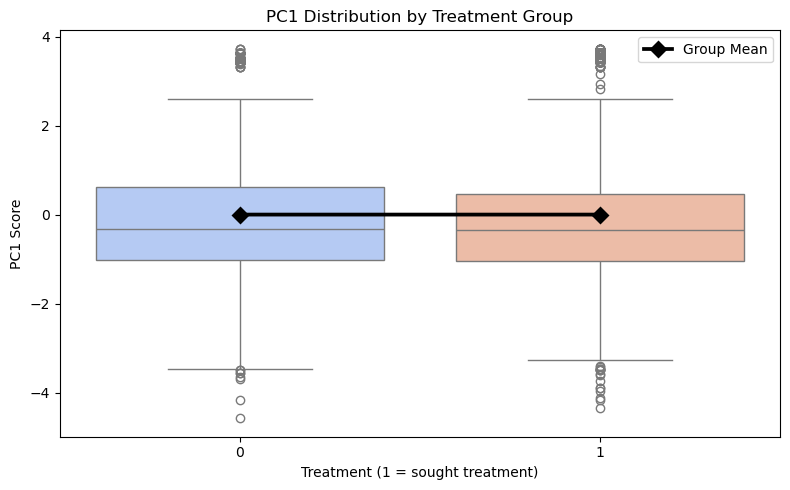

In [11]:
# Plot PC1 dsitribution by Treatment group

df_full['PC1'] = X_pca[:, 0]

plt.figure(figsize=(8,5))

sns.boxplot(x='treatment_enc', y='PC1', data=df_full, palette='coolwarm', hue='treatment_enc', legend=False)
sns.pointplot(x='treatment_enc', y='PC1', data=df_full, color='black', estimator='mean', errorbar=None, markers='D', label='Group Mean')

plt.title('PC1 Distribution by Treatment Group')
plt.xlabel('Treatment (1 = sought treatment)')
plt.ylabel('PC1 Score')
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
# Print group stats for reference
print('PC1 by Treatment Group:')
print(df_full.groupby('treatment_enc')['PC1'].agg(['mean','median']))

PC1 by Treatment Group:
                   mean    median
treatment_enc                    
0              0.000002 -0.327069
1             -0.000001 -0.350364


##### PC1 does not seem to be predictive on its own for seeking treatment
> ##### Means are essentially 0 and identical between groups
##### May interact with other variables in predictive models and still reduces dimensionality

### PC2

In [13]:
### Extract PC2 Loadings
pc2_loadings = pd.Series(pca.components_[1], index=df_full[pca_features].columns, name='PC2_Loading')

# Sort by abs value
pc2_sorted = pc2_loadings.reindex(pc2_loadings.abs().sort_values(ascending=False).index)
pc2_sorted

mental_vs_physical_enc    0.569383
obs_consequence_enc      -0.485189
family_history_enc        0.375107
work_interfere_enc        0.334273
self_employed_enc        -0.251893
wellness_program_enc     -0.182576
benefits_enc              0.173732
tech_company_enc         -0.166470
care_options_enc         -0.137027
leave_enc                 0.089695
seek_help_enc            -0.074133
anonymity_enc             0.029339
support_score            -0.009708
Name: PC2_Loading, dtype: float64

##### PC2 seems to capture individual mental health context and perception
##### Positive contributors are personal indicators
> ##### mental_vs_physical (whether mental health is taken seriously)
> ##### family_history (of mental illness)
> ##### work_intefere (whether it inteferes with work)
##### Negative contributors are workplace or situational barriers
> ##### obs_consequence (negative consequences at work)
> ##### self_employed
> ##### other workplace context: wellness_program, tech_company, care_options

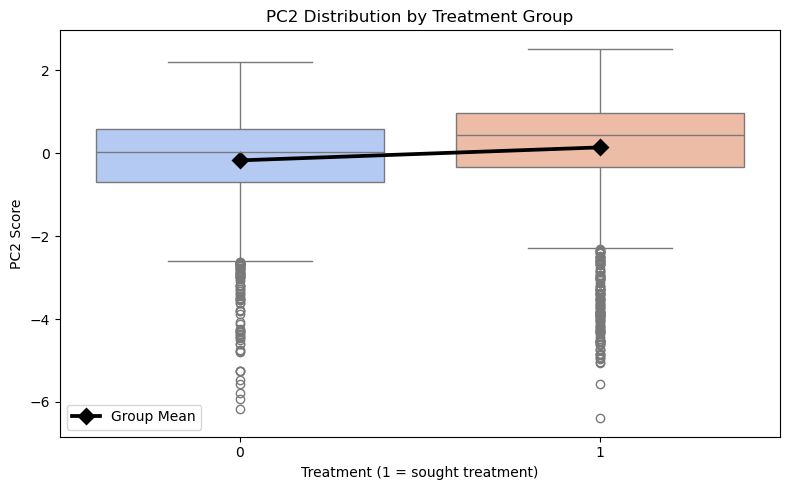

In [14]:
# Plot PC2 dsitribution by Treatment group

df_full['PC2'] = X_pca[:, 1]

plt.figure(figsize=(8,5))

sns.boxplot(x='treatment_enc', y='PC2', data=df_full, palette='coolwarm', hue='treatment_enc', legend=False)
sns.pointplot(x='treatment_enc', y='PC2', data=df_full, color='black', estimator='mean', errorbar=None, markers='D', label='Group Mean')

plt.title('PC2 Distribution by Treatment Group')
plt.xlabel('Treatment (1 = sought treatment)')
plt.ylabel('PC2 Score')
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
# Print group stats for reference
print('PC2 by Treatment Group:')
print(df_full.groupby('treatment_enc')['PC2'].agg(['mean','median']))

PC2 by Treatment Group:
                   mean    median
treatment_enc                    
0             -0.175971  0.023282
1              0.137201  0.438537


##### PC2 does seem to be a predictor for seeking treatment
> ##### 0.13 vs -0.18 mean, 0.44 vs 0.02 median
##### Can be used as an explanatory feature for modeling treatment propensity

In [16]:
# Split PC2 scores by treatment group
pc2_treatment_0 = df_full.loc[df_full['treatment_enc'] == 0, 'PC2']
pc2_treatment_1 = df_full.loc[df_full['treatment_enc'] == 1, 'PC2']

# Independent t-test
t_stat, p_val = ttest_ind(pc2_treatment_0, pc2_treatment_1, equal_var=False)  # Welch's t-test

# Effect size: Cohen's d
mean_diff = pc2_treatment_1.mean() - pc2_treatment_0.mean()
pooled_sd = np.sqrt((pc2_treatment_0.std()**2 + pc2_treatment_1.std()**2) / 2)
cohens_d = mean_diff / pooled_sd

print(f"PC2 by Treatment Group:")
print(f"Mean (treatment=0): {pc2_treatment_0.mean():.3f}")
print(f"Mean (treatment=1): {pc2_treatment_1.mean():.3f}")
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_val:.3e}")
print(f"Cohen's d: {cohens_d:.3f}")

PC2 by Treatment Group:
Mean (treatment=0): -0.176
Mean (treatment=1): 0.137
T-statistic: -8.742
P-value: 3.187e-18
Cohen's d: 0.257


##### The difference between group means is statistically signficant
> ##### t-stat: -8.742; p-value: ~3.2e-18
##### Meaningfully predictive, but effect is modest 
> ##### Cohen's d = 0.257

### PC3-10

In [17]:
# PC column names
pc_cols = [f'PC{i+1}' for i in range(X_pca.shape[1])]

# Assign PCA scores to df_full
for i, pc_name in enumerate(pc_cols):
    df_full[pc_name] = X_pca[:, i]

# Initialize results storage
pc_summary = []

# Loop over PCs 3-10
for i, pc_name in enumerate(pc_cols[2:], start=3):  # start=3 for labeling
    # Component loadings
    loadings = pd.Series(pca.components_[i-1], index=pca_features)
    top_pos = loadings.sort_values(ascending=False).head(5)
    top_neg = loadings.sort_values(ascending=True).head(5)

    # PC scores by treatment group
    scores_0 = df_full.loc[df_full['treatment_enc'] == 0, pc_name]
    scores_1 = df_full.loc[df_full['treatment_enc'] == 1, pc_name]

    # T-test (Welch)
    t_stat, p_val = ttest_ind(scores_0, scores_1, equal_var=False)

    # Cohen's d
    mean_diff = scores_1.mean() - scores_0.mean()
    pooled_sd = np.sqrt((scores_0.std()**2 + scores_1.std()**2) / 2)
    cohens_d = mean_diff / pooled_sd

    # Store results
    pc_summary.append({
        'PC': pc_name,
        'Top_Pos_Loadings': top_pos.index.tolist(),
        'Top_Neg_Loadings': top_neg.index.tolist(),
        'Mean_diff': scores_1.mean() - scores_0.mean(),
        'Median_0': scores_0.median(),
        'Median_1': scores_1.median(),
        'T_stat': t_stat,
        'P_val': p_val,
        'Cohens_d': cohens_d
    })

# Summarize
pc_summary_df = pd.DataFrame(pc_summary).sort_values(by='Cohens_d', ascending=False)
pc_summary_df

,PC,Top_Pos_Loadings,Top_Neg_Loadings,Mean_diff,Median_0,Median_1,T_stat,P_val,Cohens_d
1,PC4,"[leave_enc, work_interfere_enc, obs_consequenc...","[mental_vs_physical_enc, support_score, tech_c...",0.618687,-0.407242,0.159221,-19.819914,6.651014e-84,0.581719
0,PC3,"[support_score, wellness_program_enc, care_opt...","[anonymity_enc, benefits_enc, leave_enc, tech_...",0.518846,-0.309144,0.173177,-15.714275,3.326178e-54,0.462083
3,PC6,"[family_history_enc, tech_company_enc, obs_con...","[leave_enc, care_options_enc, self_employed_en...",0.278577,-0.212113,0.085703,-10.203783,3.622208e-24,0.302086
5,PC8,"[anonymity_enc, support_score, work_interfere_...","[benefits_enc, leave_enc, self_employed_enc, f...",0.128955,-0.098491,0.015737,-5.026992,5.179388e-07,0.148063
2,PC5,"[tech_company_enc, work_interfere_enc, care_op...","[seek_help_enc, benefits_enc, anonymity_enc, l...",0.076417,0.154119,0.199453,-2.549110,1.083356e-02,0.075155
6,PC9,"[leave_enc, seek_help_enc, tech_company_enc, s...","[care_options_enc, family_history_enc, self_em...",0.049092,0.013208,-0.044606,-1.963806,4.961624e-02,0.057972
7,PC10,"[care_options_enc, benefits_enc, support_score...","[self_employed_enc, wellness_program_enc, fami...",0.022359,-0.049376,0.007835,-0.938912,3.478308e-01,0.027861
4,PC7,"[work_interfere_enc, obs_consequence_enc, bene...","[leave_enc, family_history_enc, care_options_e...",0.013470,0.116459,0.006205,-0.514728,6.067697e-01,0.015223


##### PC4: Strongest effect; most discriminating component
##### PC3: Moderate effect; treatment vs non-treatment show meaningful separation
##### PC6: Moderate effect
##### PC8, PC5: Weak effect; small separation
##### PC9, PC10, PC7: Minimal separation; likely not useful for treatment discrimination

In [21]:
### Piece of code added retroactively to grab these results
### PC4 loadings, for Propensity Modeling analysis
pc4_loadings = pd.Series(pca.components_[3], index=df_full[pca_features].columns, name='PC4_Loading')

# Sort by abs value
pc4_sorted = pc4_loadings.reindex(pc4_loadings.abs().sort_values(ascending=False).index)
pc4_sorted

leave_enc                 0.574211
work_interfere_enc        0.487234
obs_consequence_enc       0.373320
family_history_enc        0.371609
self_employed_enc         0.224525
care_options_enc          0.208816
mental_vs_physical_enc   -0.167101
support_score            -0.128796
tech_company_enc         -0.079756
benefits_enc             -0.072721
seek_help_enc            -0.069996
anonymity_enc             0.018661
wellness_program_enc     -0.000262
Name: PC4_Loading, dtype: float64

In [20]:
pc4_sorted.to_csv('PC4_loadings.csv', index=True)

### UMAP

##### PCA assumes linear relationships among variables, so it might miss subtle patterns or clusters
> ##### PC2 may be predictive of treatment behavior, but may not fully capture interactions among variables
##### UMAP is a nonlinear dimensionality reduction technique that preserves both local and global structure
##### Useful when data has complex interactions, clusters, or latent manifolds
> ##### i.e. survey responses that mix categorical, ordinal, and binary variables
##### While PCA is helpful for feature importance and understanding what drives variance, UMAP will be used to help identify clusters and how respondents are grouped

In [17]:
# Features for dimensionality reduction
umap_features = pca_features.copy()

# Impute missing values
imputer = SimpleImputer(strategy='median')
X_umap_ready = imputer.fit_transform(df_full[umap_features])

# Standardize
scaler = StandardScaler()
X_umap_scaled = scaler.fit_transform(X_umap_ready)

In [18]:
# Fit UMAP
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(X_umap_scaled)

# Add the embeddings to the dataframe
df_full['UMAP1'] = X_umap[:, 0]
df_full['UMAP2'] = X_umap[:, 1]

C:\Users\caanm\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


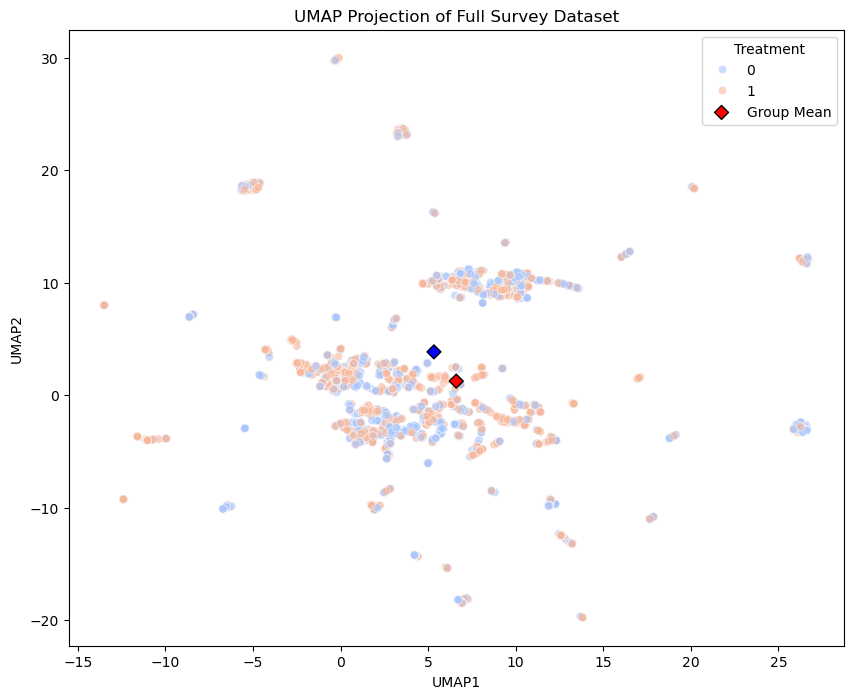

In [19]:
plt.figure(figsize=(10,8))

sns.scatterplot(
    x='UMAP1',
    y='UMAP2',
    hue='treatment_enc',
    data=df_full,
    palette='coolwarm',
    alpha=0.6
)

# Calculate group means
group_means = df_full.groupby('treatment_enc')[['UMAP1','UMAP2']].mean()

# Plot mean markers
plt.scatter(
    group_means['UMAP1'],
    group_means['UMAP2'],
    color=['red', 'blue'],
    s=50,
    marker='D',
    edgecolor='black',
    label='Group Mean'
)

plt.title('UMAP Projection of Full Survey Dataset')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.legend(title='Treatment')
plt.show()

In [20]:
# Split by treatment group
umap0 = df_full[df_full['treatment_enc'] == 0][['UMAP1', 'UMAP2']]
umap1 = df_full[df_full['treatment_enc'] == 1][['UMAP1', 'UMAP2']]

# Euclidean distance between group centroids
mean0 = umap0.mean().values
mean1 = umap1.mean().values
centroid_distance = np.linalg.norm(mean1 - mean0)

# T-tests for each axis
t_stat_UMAP1, p_val_UMAP1 = ttest_ind(umap0['UMAP1'], umap1['UMAP1'])
t_stat_UMAP2, p_val_UMAP2 = ttest_ind(umap0['UMAP2'], umap1['UMAP2'])

# Cohen's d for effect size
def cohens_d(x, y):
    nx, ny = len(x), len(y)
    pooled_std = np.sqrt(((nx-1)*np.std(x, ddof=1)**2 + (ny-1)*np.std(y, ddof=1)**2)/(nx+ny-2))
    return (np.mean(x) - np.mean(y)) / pooled_std

d_UMAP1 = cohens_d(umap0['UMAP1'], umap1['UMAP1'])
d_UMAP2 = cohens_d(umap0['UMAP2'], umap1['UMAP2'])

# Summarize results
results = {
    'UMAP_Axis': ['UMAP1', 'UMAP2'],
#    'Mean_0': [mean0[0], mean0[1]],
#    'Mean_1': [mean1[0], mean1[1]],
    'Mean_diff': [mean1[0]-mean0[0], mean1[1]-mean0[1]],
    'T_stat': [t_stat_UMAP1, t_stat_UMAP2],
    'P_val': [p_val_UMAP1, p_val_UMAP2],
    "Cohen_d": [d_UMAP1, d_UMAP2],
    "Centroid_Distance": [centroid_distance, centroid_distance]  # same distance for both axes
}

umap_stats = pd.DataFrame(results)
umap_stats

,UMAP_Axis,Mean_diff,T_stat,P_val,Cohen_d,Centroid_Distance
0,UMAP1,-1.274079,5.365598,8.457859e-08,0.158131,2.896899
1,UMAP2,2.601681,-9.370264,1.097228e-20,-0.276154,2.896899


##### UMAP2 shows stronger separation between treatment groups
> ##### t-stat: -9.37; p-value: 1e-20
> ##### Cohen's d: -0.28 (modest)
##### UMAP1 also differs significantly, but effect size is smaller
> ##### t-stat: 5.37; p-value: 8.46e-8
> ##### Cohen's d: 0.16 (small)

### PCA vs UMAP

In [21]:
cols = list(df_full.loc[:, 'PC1':'UMAP2'])
umap_cols = list(df_full.loc[:, 'UMAP1':'UMAP2'])

In [22]:
summary_list = []

for col in cols:
    values_0 = df_full[df_full['treatment_enc'] == 0][col]
    values_1 = df_full[df_full['treatment_enc'] == 1][col]
    
    mean_0 = values_0.mean()
    mean_1 = values_1.mean()
    t_stat, p_val = ttest_ind(values_0, values_1, nan_policy='omit')
    
    # Cohen's d
    n0, n1 = len(values_0), len(values_1)
    s0, s1 = values_0.std(), values_1.std()
    pooled_sd = np.sqrt(((n0-1)*s0**2 + (n1-1)*s1**2) / (n0+n1-2))
    cohen_d = (mean_1 - mean_0) / pooled_sd
    
    # Centroid distance (only meaningful for 2D UMAP)
    centroid_distance = None
    if col in umap_cols:
        x0, y0 = df_full[df_full['treatment_enc']==0][umap_cols].mean()
        x1, y1 = df_full[df_full['treatment_enc']==1][umap_cols].mean()
        centroid_distance = np.sqrt((x1-x0)**2 + (y1-y0)**2)
    
    summary_list.append({
        'Axis': col,
        'Mean_diff': mean_1 - mean_0,
        'T_stat': t_stat,
        'P_val': p_val,
        'Cohens_d': cohen_d,
        'Centroid_Distance': centroid_distance
    })

summary_df = pd.DataFrame(summary_list).sort_values(by='Cohens_d', ascending=False)
summary_df

,Axis,Mean_diff,T_stat,P_val,Cohens_d,Centroid_Distance
3,PC4,0.618687,-19.657962,9.982725e-83,0.579347,NaN
2,PC3,0.518846,-15.644060,8.266821e-54,0.461052,NaN
5,PC6,0.278577,-10.297178,1.326670e-24,0.303472,NaN
11,UMAP2,2.601681,-9.370264,1.097228e-20,0.276154,2.896899
1,PC2,0.313171,-8.688417,5.008170e-18,0.256059,NaN
7,PC8,0.128955,-5.020972,5.332267e-07,0.147975,NaN
4,PC5,0.076417,-2.551102,1.076986e-02,0.075184,NaN
8,PC9,0.049092,-1.970340,4.885832e-02,0.058069,NaN
9,PC10,0.022359,-0.951932,3.411805e-01,0.028055,NaN
6,PC7,0.013470,-0.518374,6.042216e-01,0.015277,NaN


##### PCA components capture more of the treatment-related structure than the individual UMAP axes
> ##### PC3, PC4, and PC6 most informative axes for quantitative modeling or feature selection
##### UMAP still helpful for 2D visualization
> ##### UMAP 2 better for showing treatment vs non-treatment clusters in 2D
> ##### UMAP 1 provides a complementary dimension


### Save data for Clustering

In [23]:
df_full.to_csv('full_data.csv', index=False)